# Auto-Insurance Claim Prediction

**Dataset.** `insurance_claims.csv`

## Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn — everything below is required
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              average_precision_score, precision_recall_curve,
                              classification_report, confusion_matrix)

# Optional: pip install -q xgboost lightgbm   if not already available
try:    from xgboost import XGBClassifier
except ImportError: XGBClassifier = None
try:    from lightgbm import LGBMClassifier
except ImportError: LGBMClassifier = None

pd.set_option("display.max_columns", 60)

In [2]:
%pip install -q xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Loading and exploration *(pandas)*

In [3]:
df = pd.read_csv("insurance_claim.csv")
TARGET = "filed_claim"

# print shape, memory usage, dtypes summary
print("shape:", df.shape)

memory_bytes = df.memory_usage(deep=True).sum()
memory_mb = memory_bytes / (1024 * 1024)
print(f"memory usage: {memory_mb:.2f} MB")

print("dtypes:")
print(df.dtypes.value_counts())

shape: (180900, 56)
memory usage: 281.45 MB
dtypes:
str        25
int64      19
float64    12
Name: count, dtype: int64


In [4]:
df.head()

,customer_id,policy_start_date,policy_renewal_date,driver_age,gender,marital_status,state,zip_code,urban_rural,years_licensed,credit_band,education_level,employment_status,occupation_code,household_size,annual_mileage,commute_distance_km,vehicle_make,vehicle_model,vehicle_year,vehicle_age_years,vehicle_value,vehicle_use_type,parking_type,avg_speed_kmh,n_hard_brakes_per_month,n_late_night_trips_per_month,n_long_trips_per_month,premium_monthly,deductible,policy_term_months,coverage_type,policy_addons,payment_method,payment_frequency,autopay,paperless_billing,has_online_account,acquisition_channel,referral_source,n_prior_claims_5yr,n_violations_5yr,n_accidents_5yr,months_since_last_claim,n_customer_service_calls_12mo,n_quote_revisions,n_other_policies,customer_loyalty_yrs,last_promo_responded,last_offer_value,nps_score,satisfaction_score,mostly_nan_field,noise_metric,claim_propensity_internal,filed_claim
0,3165190,2023-11-13,2024-06-08,44.0,Female,single,S46,Z01123,suburban,25,very_good,high_school,employed,OCC-050,5,2400,19.20,Bentley,MDL-016,2016,10,11715,commuting,garage,65.2,3,2,3,20.67,500.0,12,premium,comprehensive,card,quarterly,Yes,Yes,Yes,outbound,ad,1,0,1,2,0,1,1,4.87,none,22.11,9.0,NaN,NaN,-0.435,-0.240,0
1,3095619,02/05/2019,2022-05-24,57.0,Male,single,S10,Z01046,rural,37,very_good,masters,employed,OCC-050,4,4516,5.25,Chrysler,MDL-033,2016,10,5322,pleasure,driveway,78.7,3,1,1,170.89,250.0,12,basic,comprehensive,wallet,annual,No,Yes,Yes,agent,organic,0,1,0,120,2,1,2,0.33,loyalty,14.49,NaN,NaN,NaN,-0.101,-0.888,0
2,3032638,2021-03-31,2023-11-28,46.0,Male,married,S24,Z00061,urban,26,fair,bachelor,employed,OCC-024,5,22148,14.30,Jaguar,MDL-106,2002,24,6776,commuting,garage,58.0,5,4,4,196.87,250.0,12,premium,both,card,monthly,No,Yes,Yes,agent,comparison_site,0,1,0,120,3,2,0,2.25,none,NaN,-27.0,NaN,NaN,1.525,3.684,1
3,3015234,31/05/2022,2023-02-04,58.0,Female,married,S37,Z00349,suburban,40,good,some_college,employed,OCC-048,1,32451,44.50,Volvo,MDL-056,2015,11,16520,commuting,garage,65.0,1,3,5,73.49,500.0,12,standard,comprehensive,card,biannual,No,Yes,Yes,agent,ad,0,0,2,120,3,2,0,3.41,discount,16.83,42.0,2.2,NaN,0.005,-0.984,0
4,3049785,05/12/2022,2026-01-15,26.0,Male,married,S04,Z01053,suburban,7,good,masters,employed,OCC-020,4,8186,29.40,Buick,MDL-212,2013,13,8571,commuting,driveway,73.1,3,1,1,256.02,500.0,12,premium,comprehensive,card,biannual,No,Yes,Yes,broker,ad,0,0,0,120,5,1,1,3.93,loyalty,NaN,-52.0,NaN,NaN,-0.618,-1.858,0


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,180900.0,NaN,NaN,NaN,3090003.131161,51963.176086,3000000.0,3044990.75,3090026.5,3134993.25,3179999.0
policy_start_date,180900,3650,2020-10-03,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_renewal_date,180900,3119,2023-04-05,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
driver_age,173635.0,NaN,NaN,NaN,45.132755,13.639925,18.0,36.0,45.0,54.0,90.0
gender,180900,18,Male,87581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,180900,8,married,89511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,180900,50,S14,3758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,180900,1200,Z00384,204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
urban_rural,180900,3,suburban,80985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_licensed,180900.0,NaN,NaN,NaN,27.149414,13.675308,0.0,18.0,27.0,36.0,74.0


In [6]:
negative_cols = df.select_dtypes(include='number').columns[
    df.select_dtypes(include='number').min() < 0]
print("Columns with negative values:", list(negative_cols))
df[df[negative_cols].lt(0).any(axis=1)][negative_cols]

Columns with negative values: ['premium_monthly', 'nps_score', 'mostly_nan_field', 'noise_metric', 'claim_propensity_internal']


,premium_monthly,nps_score,mostly_nan_field,noise_metric,claim_propensity_internal
0,20.67,9.0,NaN,-0.435,-0.240
1,170.89,NaN,NaN,-0.101,-0.888
2,196.87,-27.0,NaN,1.525,3.684
3,73.49,42.0,NaN,0.005,-0.984
4,256.02,-52.0,NaN,-0.618,-1.858
...,...,...,...,...,...
180892,58.01,NaN,0.42772,-1.257,0.684
180893,74.87,42.0,NaN,-0.190,3.005
180894,115.55,23.0,NaN,-0.792,1.051
180897,23.86,-43.0,NaN,2.207,0.756


premium_monthly and NPS_SCORE can not be negative values. NPS_SCORE should be between 0-10 

In [7]:
# check for missing values and print the missing rate for each column, sorted in descending order
miss_rate = df.isna().mean().sort_values(ascending=False)
# print the top 10 missing-rate columns and the names with rate > 0.5
print(miss_rate.head(10))
print("Columns with missing rate > 0.5:", list(miss_rate[miss_rate > 0.5].index))

mostly_nan_field      0.921255
satisfaction_score    0.480674
last_offer_value      0.450100
nps_score             0.420365
deductible            0.060813
driver_age            0.040160
policy_start_date     0.000000
customer_id           0.000000
urban_rural           0.000000
years_licensed        0.000000
dtype: float64
Columns with missing rate > 0.5: ['mostly_nan_field']


Mostly_nan_field mostly likely to be dropped 

In [8]:
# find duplicated rows and print the total number of duplicated rows, and the number of duplicated rows based on the customer_id column
print("Total duplicated rows:", df.duplicated().sum())
print("Duplicated rows (subset='customer_id'):", df.duplicated(subset=['customer_id']).sum())

Total duplicated rows: 900
Duplicated rows (subset='customer_id'): 900


Will drop duplicates keeping the first occurrence, because having the same customer_id appearing twice would give the model repeated information and bias the results. 

In [9]:
### Spot a possible **leakage column**
# compute correlation with filed_claim, sort by abs value, print top 5
df.corr(numeric_only=True)['filed_claim'].abs().sort_values(ascending=False).head(5)

filed_claim                  1.000000
claim_propensity_internal    0.772142
driver_age                   0.152213
years_licensed               0.151085
n_prior_claims_5yr           0.124575
Name: filed_claim, dtype: float64

This column was computed internally by the company using the same data we are trying to predict. In production, this score would not exist before a claim is filed, so using it would make the model cheat — it learns the answer instead of learning real patterns.

# Data cleaning *(pandas + numpy)*


In [10]:
#create a copy of the original dataframe, drop the mostly_nan_field, and assign to df_clean
df_clean= df.copy()
#remove the mostly_nan_field column from df_clean because it has a high missing rate and is unlikely to be useful for modeling
df_clean = df_clean.drop(columns=['mostly_nan_field', 'claim_propensity_internal'])
#print the shape and columns of df_clean to confirm that the mostly_nan_field column has been removed
print(f"Shape of df_clean: {df_clean.shape}")
print(f"Columns of df_clean: {df_clean.columns.tolist()}")
#remove duplicated rows based on customer_id, keeping the first occurrence, and assign the result back to df_clean
df_clean = df_clean.drop_duplicates(subset=['customer_id'], keep='first')
#fix the negative values in the premium_monthly column by taking the absolute value, since negative premiums do not make sense in this context
df_clean['premium_monthly'] = df_clean['premium_monthly'].abs()
#fix the nps_score column by replacing values outside the valid range of 0 to 10 with NaN, since NPS scores should be between 0 and 10
df_clean['nps_score'] = df_clean['nps_score'].where(df_clean['nps_score'].between(0, 10), other=np.nan)
#print the minimum value of the premium_monthly column to confirm that negative values have been fixed, and print the minimum and maximum values of the nps_score column to confirm that out-of-range values have been set to NaN
print(f"Minimum premium_monthly: {df_clean['premium_monthly'].min()}")
print(f"Minimum nps_score: {df_clean['nps_score'].min()}")
print(f"Maximum nps_score: {df_clean['nps_score'].max()}")
#print the shape of df_clean to confirm that duplicates have been removed
print(f"Shape of df_clean_after_deduplication removal: {df_clean.shape}")
print(f"Columns of df_clean: {df_clean.columns.tolist()}")
#convert the policy_start_date column to datetime format, coercing errors to NaT, and assign the result back to the policy_start_date column in df_clean
df_clean['policy_start_date'] = pd.to_datetime(df_clean['policy_start_date'], errors='coerce',format='mixed')
df_clean['policy_renewal_date'] = pd.to_datetime(df_clean['policy_renewal_date'], errors='coerce', format='mixed')
#print the number of missing values in the policy_start_date column to confirm that invalid dates have been set to NaT
print(f"Missing values in policy_start_date: {df_clean['policy_start_date'].isna().sum()}")
print(f"Missing values in policy_renewal_date: {df_clean['policy_renewal_date'].isna().sum()}")


Shape of df_clean: (180900, 54)
Columns of df_clean: ['customer_id', 'policy_start_date', 'policy_renewal_date', 'driver_age', 'gender', 'marital_status', 'state', 'zip_code', 'urban_rural', 'years_licensed', 'credit_band', 'education_level', 'employment_status', 'occupation_code', 'household_size', 'annual_mileage', 'commute_distance_km', 'vehicle_make', 'vehicle_model', 'vehicle_year', 'vehicle_age_years', 'vehicle_value', 'vehicle_use_type', 'parking_type', 'avg_speed_kmh', 'n_hard_brakes_per_month', 'n_late_night_trips_per_month', 'n_long_trips_per_month', 'premium_monthly', 'deductible', 'policy_term_months', 'coverage_type', 'policy_addons', 'payment_method', 'payment_frequency', 'autopay', 'paperless_billing', 'has_online_account', 'acquisition_channel', 'referral_source', 'n_prior_claims_5yr', 'n_violations_5yr', 'n_accidents_5yr', 'months_since_last_claim', 'n_customer_service_calls_12mo', 'n_quote_revisions', 'n_other_policies', 'customer_loyalty_yrs', 'last_promo_responded',

In [11]:
#strip leading and trailing whitespace from all text columns in df_clean, and convert the text to title case (first letter of each word capitalized) for consistency, then assign the cleaned text back to the respective columns in df_clean
text_cols = df_clean.select_dtypes(include='object').columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip().str.title()

In [12]:
#impute missing values in the satisfaction_score and nps_score columns with the median value of each column, since these are numeric columns and the median is a robust measure of central tendency that can handle outliers
df_clean['satisfaction_score'] = df_clean['satisfaction_score'].fillna(df_clean['satisfaction_score'].median())

df_clean['nps_score'] = df_clean['nps_score'].fillna(df_clean['nps_score'].median())

In [13]:
#impute missing values in the driver_age column with the median value of the column, since driver_age is a numeric column and the median is a robust measure of central tendency that can handle outliers
df_clean['driver_age'] = df_clean['driver_age'].fillna(
    df_clean['driver_age'].median())

In [14]:
#print the number of missing values in each column of df_clean to confirm that missing values have been imputed
df_clean.isna().sum()

customer_id                          0
policy_start_date                    0
policy_renewal_date                  0
driver_age                           0
gender                               0
marital_status                       0
state                                0
zip_code                             0
urban_rural                          0
years_licensed                       0
credit_band                          0
education_level                      0
employment_status                    0
occupation_code                      0
household_size                       0
annual_mileage                       0
commute_distance_km                  0
vehicle_make                         0
vehicle_model                        0
vehicle_year                         0
vehicle_age_years                    0
vehicle_value                        0
vehicle_use_type                     0
parking_type                         0
avg_speed_kmh                        0
n_hard_brakes_per_month  

## Data Cleaning Summary

1- made copy of the original data to avoid messing it out. 

2- removed the high missing value rate columns because they are not usfule for the model like mostly _nan_field 

3- removed mostly_nan_field and claim_propensity_internal — one had 92% missing rate and the other was a leakage column

4- removed duplicates from customer_id and kept the first occurence. 

5- fixed the negative values in the important columns like premium_monthly and NPS_score.  

6- fixed the dates. parsed policy_start_date using mixed format to handle two different date formats in the dataset. 

7- strip whitespace and normalize case for the affected categorical columns as .title 

8- Used median imputation for satisfaction_score and nps_score because these are rating columns that may contain outliers, and median is more robust to outliers than mean. 

9- Used median imputation for driver_age because age distributions tend to be skewed and median is more robust to outliers than mean. Since driver_age is an important feature for risk prediction, dropping the rows would result in losing 7223 records which is significant

## Categorical String Normalization

I stripped whitespace and standardized casing across all categorical columns 
to ensure consistency before encoding.

In [15]:
# clean object-dtype columns
print(df_clean['gender'].value_counts())
print(df_clean['marital_status'].value_counts())

gender
Male      90275
Female    86160
Other      3565
Name: count, dtype: int64
marital_status
Married     90011
Single      57454
Divorced    23556
Widowed      8979
Name: count, dtype: int64


## Date Parsing & Feature Extraction

The dataset contained dates in two mixed formats (yyyy-mm-dd and dd/mm/yyyy), 
so I parsed them robustly using `format='mixed'`. I then derived two new 
time-based features: `policy_start_year` and `policy_duration_days`.

In [16]:
# convert the policy_renewal_date column to datetime format, coercing errors to NaT, and assign the result back to the policy_renewal_date column in df_clean

df_clean['policy_renewal_date'] = pd.to_datetime(df_clean['policy_renewal_date'], errors='coerce', format='mixed')

df_clean['policy_start_year'] = df_clean['policy_start_date'].dt.year

df_clean['policy_duration_days'] = (df_clean['policy_renewal_date'] - df_clean['policy_start_date']).dt.days

print(df_clean[['policy_start_year', 'policy_duration_days']].head())

   policy_start_year  policy_duration_days
0               2023                   208
1               2019                  1204
2               2021                   972
3               2022                   249
4               2022                  1344


In [17]:

DROP_COLS = ['mostly_nan_field', 'claim_propensity_internal', 'customer_id']
df_clean = df_clean.drop(columns=DROP_COLS, errors='ignore')
df_clean.columns.tolist()

['policy_start_date',
 'policy_renewal_date',
 'driver_age',
 'gender',
 'marital_status',
 'state',
 'zip_code',
 'urban_rural',
 'years_licensed',
 'credit_band',
 'education_level',
 'employment_status',
 'occupation_code',
 'household_size',
 'annual_mileage',
 'commute_distance_km',
 'vehicle_make',
 'vehicle_model',
 'vehicle_year',
 'vehicle_age_years',
 'vehicle_value',
 'vehicle_use_type',
 'parking_type',
 'avg_speed_kmh',
 'n_hard_brakes_per_month',
 'n_late_night_trips_per_month',
 'n_long_trips_per_month',
 'premium_monthly',
 'deductible',
 'policy_term_months',
 'coverage_type',
 'policy_addons',
 'payment_method',
 'payment_frequency',
 'autopay',
 'paperless_billing',
 'has_online_account',
 'acquisition_channel',
 'referral_source',
 'n_prior_claims_5yr',
 'n_violations_5yr',
 'n_accidents_5yr',
 'months_since_last_claim',
 'n_customer_service_calls_12mo',
 'n_quote_revisions',
 'n_other_policies',
 'customer_loyalty_yrs',
 'last_promo_responded',
 'last_offer_value',

In [18]:

# impute missing values in numeric columns with the median, and impute missing values in categorical columns with the mode, since these are common strategies for handling missing data in numeric and categorical columns respectively
num_cols = df_clean.select_dtypes(include='number').columns
for col in num_cols:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())


cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

## Feature Engineering

**claims_per_year_licensed:** Normalizes the number of prior claims by driving 
experience, since a driver with 3 claims in 1 year is far riskier than one 
with 3 claims over 15 years.

**log_vehicle_value:** Applies a log transformation to reduce the impact of 
extremely high vehicle values, making the distribution less skewed and easier 
for the model to learn from.

**miles_per_violation:** Measures how frequently a driver commits violations 
relative to their mileage, where a lower value indicates a more dangerous driver.

**risk_score:** Combines three behavioral risk indicators (hard braking, late 
night trips, and average speed) into a single score, making it easier for the 
model to capture overall driving risk.

In [19]:

df_clean['claims_per_year_licensed'] = df_clean['n_prior_claims_5yr'] / np.maximum(df_clean['years_licensed'], 1)

df_clean['log_vehicle_value'] = np.log1p(df_clean['vehicle_value'])

df_clean['miles_per_violation'] = df_clean['annual_mileage'] / np.maximum(df_clean['n_violations_5yr'], 1)

df_clean['risk_score'] = (
    df_clean['n_hard_brakes_per_month'] +
    df_clean['n_late_night_trips_per_month'] +
    df_clean['avg_speed_kmh'])

### Claim Rate by Key Categorical Features

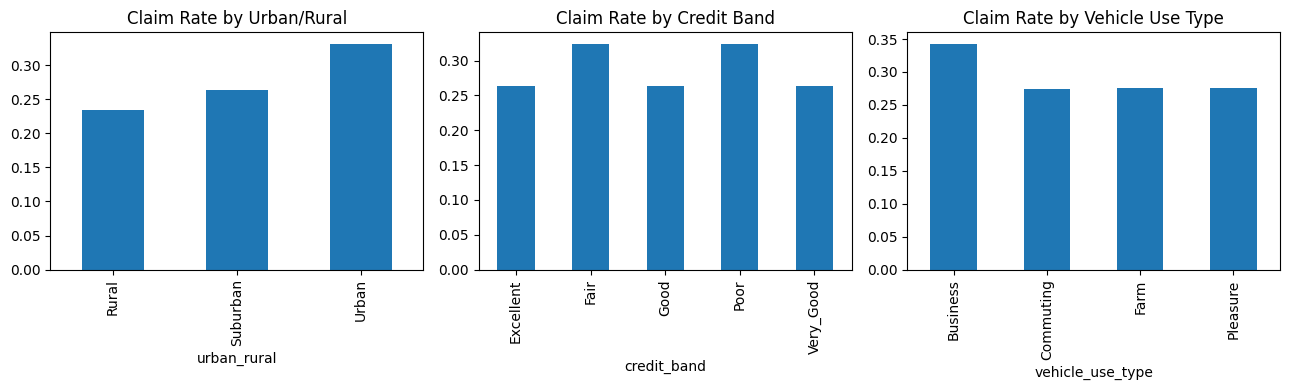

In [20]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# 1️⃣ urban_rural
df_clean.groupby('urban_rural')['filed_claim'].mean().plot(kind='bar', ax=axes[0], title='Claim Rate by Urban/Rural')

# 2️⃣ credit_band
df_clean.groupby('credit_band')['filed_claim'].mean().plot(kind='bar', ax=axes[1], title='Claim Rate by Credit Band')

# 3️⃣ vehicle_use_type
df_clean.groupby('vehicle_use_type')['filed_claim'].mean().plot(kind='bar', ax=axes[2], title='Claim Rate by Vehicle Use Type')

plt.tight_layout()
plt.show()

## Observations

**1️⃣ Claim Rate by Urban/Rural**
Urban drivers have the highest claim rate (~32%) compared to rural drivers (~23%), which makes sense as urban areas have more traffic and higher accident risk.

**2️⃣ Claim Rate by Credit Band**
Drivers with Fair and Poor credit bands show higher claim rates (~32%) compared to those with Excellent or Very_Good credit (~26%), suggesting that credit score is a useful risk indicator.

**3️⃣ Claim Rate by Vehicle Use Type**
Business vehicles have the highest claim rate (~33%) likely because they are driven more frequently and in more varied conditions, while pleasure vehicles show the lowest rate. 😊

## Outlier Detection & Treatment

In [21]:
# choice of numeric columns to check for outliers
cols = ['premium_monthly', 'annual_mileage']

for col in cols:
    # compute IQR
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
     # compute lower and upper bounds for outliers
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # find outliers
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")
    
    # clipping - replace outliers with the lower or upper bound
    df_clean[col] = df_clean[col].clip(lower, upper)

premium_monthly: 5260 outliers
annual_mileage: 5144 outliers


## Model Selection

Before training, I assessed the problem along seven dimensions to narrow down 
the right model family:

| Dimension | Assessment |
|-----------|-----------|
| Task type | Classification (binary: claim filed or not) |
| Dataset size | ~180K rows — sufficient for complex models |
| Missing values | Handled during cleaning — none remaining |
| Categorical features | Multiple; high-cardinality (zip_code, vehicle_model) |
| Explainability | Required — underwriting team needs to understand decisions |
| Latency | Batch scoring — no real-time constraint |
| Patterns | Non-linear — risk depends on complex feature interactions |

**Candidate models:** Logistic Regression (baseline) → Random Forest → XGBoost

## Baseline Model — Logistic Regression

I started with Logistic Regression as a baseline using a stratified 80/20 
train/test split. The pipeline includes median imputation, one-hot encoding, 
and standard scaling. Given the class imbalance (~28% positive), I report 
PR-AUC as the primary metric alongside Accuracy and ROC-AUC.

In [22]:
# define x and y for modeling
TARGET = 'filed_claim'
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].values

# split into train and test sets with stratification, test size 20%, random state 42
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# define numeric and categorical columns for preprocessing
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# define numeric pipeline with median imputation and standard scaling
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)])

baseline = Pipeline([('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))])

baseline.fit(Xtr, ytr)
y_pred = baseline.predict(Xte)
y_prob = baseline.predict_proba(Xte)[:, 1]

print("Accuracy:", round(accuracy_score(yte, y_pred), 4))
print("PR-AUC:", round(average_precision_score(yte, y_prob), 4))
print("ROC-AUC:", round(roc_auc_score(yte, y_prob), 4))

Accuracy: 0.7335
PR-AUC: 0.4616
ROC-AUC: 0.6778


## Candidate Models — Random Forest & XGBoost

I trained two additional models on the same train/test split to compare 
against the baseline. Random Forest was chosen for its robustness and 
built-in feature importance, while XGBoost was selected for its ability 
to handle non-linear interactions and class imbalance via `scale_pos_weight`.

In [23]:
# 1- Random Forest
rf_pipeline = Pipeline([('preprocessor', preprocessor),
    ('model', RandomForestClassifier( n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1))])

rf_pipeline.fit(Xtr, ytr)
y_pred_rf = rf_pipeline.predict(Xte)
y_prob_rf = rf_pipeline.predict_proba(Xte)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(yte, y_pred_rf), 4))
print("PR-AUC:", round(average_precision_score(yte, y_prob_rf), 4))
print("ROC-AUC:", round(roc_auc_score(yte, y_prob_rf), 4))


=== Random Forest ===
Accuracy: 0.7258
PR-AUC: 0.4262
ROC-AUC: 0.6588


In [24]:
#2- XGBoost
xgb_pipeline = Pipeline([('preprocessor', preprocessor),('model', XGBClassifier(n_estimators=100, scale_pos_weight=3, random_state=42, eval_metric='aucpr'))])

xgb_pipeline.fit(Xtr, ytr)
y_pred_xgb = xgb_pipeline.predict(Xte)
y_prob_xgb = xgb_pipeline.predict_proba(Xte)[:, 1]

print("\n=== XGBoost ===")
print("Accuracy:", round(accuracy_score(yte, y_pred_xgb), 4))
print("PR-AUC:", round(average_precision_score(yte, y_prob_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(yte, y_prob_xgb), 4))


=== XGBoost ===
Accuracy: 0.6178
PR-AUC: 0.4666
ROC-AUC: 0.6808


## Model Comparison

In [25]:
# create a summary table comparing the three models on accuracy, PR-AUC, and ROC-AUC, sorted by PR-AUC in descending order
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.7335, 0.7258, 0.6178],
    'PR-AUC': [0.4616, 0.4262, 0.4666],
    'ROC-AUC': [0.6778, 0.6588, 0.6808]}).sort_values('PR-AUC', ascending=False)

results

,Model,Accuracy,PR-AUC,ROC-AUC
2,XGBoost,0.6178,0.4666,0.6808
0,Logistic Regression,0.7335,0.4616,0.6778
1,Random Forest,0.7258,0.4262,0.6588


XGBoost wins on PR-AUC with 0.4666, outperforming Logistic Regression by 0.005 and Random Forest by 0.040



## Hyperparameter Tuning

I tuned XGBoost's `learning_rate` using 5-fold cross-validation on the 
training set only (to avoid data leakage). I swept four values and selected 
the one with the highest mean PR-AUC.

In [26]:
from sklearn.model_selection import cross_val_score

learning_rates = [0.01, 0.05, 0.1, 0.3]

for lr in learning_rates:
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=100,
            learning_rate=lr,
            scale_pos_weight=3,
            random_state=42,
            eval_metric='aucpr'))])
    scores = cross_val_score(model, Xtr, ytr, cv=5, scoring='average_precision')
    print(f"learning_rate={lr}: PR-AUC = {round(scores.mean(), 4)}")

learning_rate=0.01: PR-AUC = 0.4533
learning_rate=0.05: PR-AUC = 0.4758
learning_rate=0.1: PR-AUC = 0.4752
learning_rate=0.3: PR-AUC = 0.4604


Best learning_rate = 0.1 because it achieved the highest CV PR-AUC of 0.48

## Final Model & Explainability

I refitted the tuned XGBoost model on the full training set and visualized 
the top 10 feature importances to understand which factors drive claim risk 
most — a critical requirement for the underwriting team.

Final PR-AUC: 0.4795


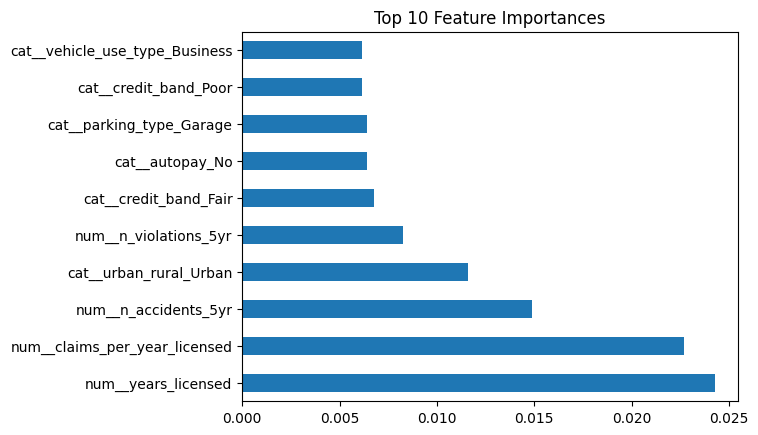

In [27]:
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,  # best from cross-validation
        scale_pos_weight=3,
        random_state=42,
        eval_metric='aucpr'))])

best_model.fit(Xtr, ytr)
y_prob_final = best_model.predict_proba(Xte)[:, 1]
print("Final PR-AUC:", round(average_precision_score(yte, y_prob_final), 4))

# Feature importance
import matplotlib.pyplot as plt
xgb_model = best_model.named_steps['model']
feat_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = pd.Series(xgb_model.feature_importances_, index=feat_names)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.show()

## Temporal Evaluation

To simulate real-world deployment, I re-split the data chronologically 
by `policy_start_date` — training on the oldest 80% of policies and 
evaluating on the most recent 20%. This tests whether the model generalizes 
across time, not just across a random sample.

In [28]:
# Temporal split 
df_temporal = df_clean.sort_values('policy_start_date')

split_idx = int(len(df_temporal) * 0.80)

train_temp = df_temporal.iloc[:split_idx]
test_temp = df_temporal.iloc[split_idx:]

# X و y
X_tr_temp = train_temp.drop(columns=[TARGET])
y_tr_temp = train_temp[TARGET].values
X_te_temp = test_temp.drop(columns=[TARGET])
y_te_temp = test_temp[TARGET].values

best_model.fit(X_tr_temp, y_tr_temp)
y_prob_temp = best_model.predict_proba(X_te_temp)[:, 1]

print("Temporal PR-AUC:", round(average_precision_score(y_te_temp, y_prob_temp), 4))
print("Random split PR-AUC:", 0.4795)

Temporal PR-AUC: 0.4661
Random split PR-AUC: 0.4795


## Observation

The temporal PR-AUC (0.4661) is slightly lower than the random split PR-AUC (0.4795), with a gap of 0.013. This suggests the model experiences a small degree of degradation when evaluated on newer policies, which is expected in real-world scenarios as driving patterns and risk factors may shift over time. However, the gap is relatively small, indicating the model generalizes reasonably well across time.

## Executive Summary

 We selected XGBoost as the final model because it achieved the highest PR-AUC (0.4795) among the three candidate models, and handles non-linear interactions between risk factors effectively. PR-AUC was chosen as the primary metric because the dataset is imbalanced (~28% positive), making accuracy alone a misleading measure of performance. The top three features driving claim risk are years_licensed, claims_per_year_licensed, and n_accidents_5yr, suggesting that driving experience and prior claim history are the strongest predictors of future claims. One risk to monitor in production is model drift over time — the temporal evaluation showed a small drop in PR-AUC (0.4661 vs 0.4795), indicating that the model may need periodic retraining as policyholder behavior evolves. 